This file is for deciding what freezing strategy to use 

From previous files, the lr for head is 0.0017378008365631102 and lr range for whole model is ((1.9054607491852948e-06)/10, (1.9054607491852948e-06)/4)
The no. of epochs for head remains const. at 3 and no. of epochs for whole model is 8 as found in prev. file
The batch size found is 16 from prev. file
The weight decay found is 1e-3
The optimizer found is RMSProp
The lr_scheduler found is OneCycleLR

I will be doing these experiments

1. Train only head

2. Head->unfreeze all 

3. Train entire model from beginning

So here goes our first experimnet in which i will be traing only head

In [1]:
import pandas as pd
import regex as re
from fastai.vision.all import *

In [2]:
df = pd.read_csv(r'D:\Traffic\labels_processed.csv')

In [3]:
def label_function(dpath):
    class_name = re.findall(r'(\d+)_.*\.png$', dpath.name)
    class_id = int(class_name[0])
    return df['Names'][class_id]

In [4]:
signs = DataBlock(blocks = (ImageBlock, CategoryBlock),
                  get_items = get_image_files,
                  splitter = RandomSplitter(seed = 42),
                  get_y = label_function,
                  item_tfms = Resize(224),
                  batch_tfms = aug_transforms(size = 224, min_scale = 0.75, do_flip = False))

In [5]:
path = Path(r'D:\Traffic\traffic_Data_processed\DATA')

In [6]:
lr_head = 0.0017378008365631102
lr_whole_model = 1.9054607491852948e-06

In [7]:
set_seed(42, reproducible = True)

In [8]:
dls_7_1 = signs.dataloaders(path, bs = 16)

In [10]:
model_7_1 = vision_learner(dls_7_1, arch = resnet34, metrics = error_rate, opt_func = RMSProp)
model_7_1.fit_one_cycle(11, lr_head, wd = 1e-3)

epoch,train_loss,valid_loss,error_rate,time
0,1.637769,0.533068,0.124096,00:25
1,0.454536,0.135991,0.042169,00:24
2,0.241018,0.050466,0.016867,00:24
3,0.104049,0.034555,0.014458,00:25
4,0.070282,0.008179,0.001205,00:25
5,0.044473,0.002915,0.001205,00:25
6,0.024559,0.000366,0.000000,00:25
7,0.020101,0.000571,0.000000,00:26
8,0.012429,0.000648,0.000000,00:27
9,0.005000,0.000227,0.000000,00:26


In [11]:
set_seed(42, reproducible = True)

In [12]:
dls_7_2 = signs.dataloaders(path, bs = 16)

In [13]:
model_7_2 = vision_learner(dls_7_2, arch = resnet34, metrics = error_rate, opt_func = RMSProp)
model_7_2.fit_one_cycle(3, lr_head, wd = 1e-3)
model_7_2.unfreeze()
model_7_2.fit_one_cycle(8, lr_max = slice(lr_whole_model/10, lr_whole_model/4), wd = 1e-3)

epoch,train_loss,valid_loss,error_rate,time
0,0.786328,0.190654,0.055422,00:21
1,0.191432,0.049008,0.015663,00:21
2,0.079777,0.022944,0.003614,00:21


epoch,train_loss,valid_loss,error_rate,time
0,0.083987,0.024915,0.008434,00:32
1,0.079429,0.022036,0.003614,00:34
2,0.065454,0.019609,0.003614,00:28
3,0.070738,0.021263,0.006024,00:28
4,0.061640,0.019952,0.004819,00:30
5,0.060167,0.017512,0.004819,00:29
6,0.066579,0.019838,0.004819,00:30
7,0.066935,0.018061,0.002410,00:34


In [14]:
set_seed(42, reproducible = True)

In [15]:
dls_7_3 = signs.dataloaders(path, bs = 16)

In [ ]:
model_7_3 = vision_learner(dls_7_3, arch = resnet34, metrics = error_rate, opt_func = RMSProp)
model_7_3.unfreeze()
model_7_3.fit_one_cycle(11, lr_max = slice(lr_whole_model/10, lr_whole_model/4), wd = 1e-3)

epoch,train_loss,valid_loss,error_rate,time
0,5.852031,4.754595,0.983133,00:33
1,5.679916,4.685046,0.973494,00:41
2,5.608136,4.477447,0.946988,00:41
3,5.501852,4.314431,0.926506,00:41
4,5.287176,4.216847,0.913253,00:32
5,5.171170,4.054299,0.886747,00:28
6,5.049512,3.965364,0.871084,00:33
7,5.049190,3.925337,0.861446,00:28
8,5.061792,3.910478,0.848193,00:29
9,4.990690,3.879674,0.838554,00:40


Ok so as lr was too high for early layers and so rerunning this experiment to conclude

In [17]:
set_seed(42, reproducible = True)

In [18]:
dls_7_4 = signs.dataloaders(path, bs = 16)

<div></div>

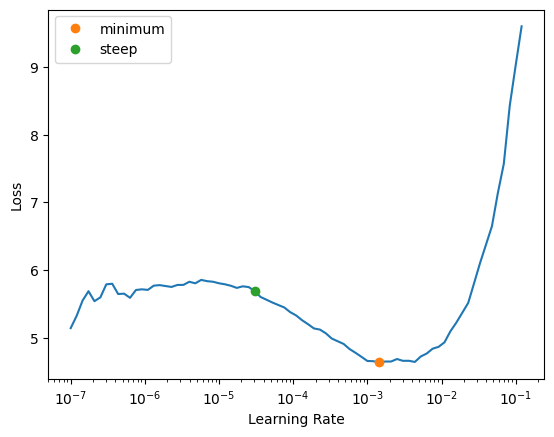

In [19]:
model_7_4 = vision_learner(dls_7_4, arch = resnet34, metrics = error_rate, opt_func = RMSProp)
model_7_4.unfreeze()
lr_min, lr_steep = model_7_4.lr_find(suggest_funcs=(minimum,steep))

In [20]:
lr_min, lr_steep

(0.00014454397605732084, 3.0199516913853586e-05)

In [21]:
model_7_3 = vision_learner(dls_7_3, arch = resnet34, metrics = error_rate, opt_func = RMSProp)
model_7_3.unfreeze()
model_7_3.fit_one_cycle(11, lr_max = slice(lr_steep/10, lr_steep), wd = 1e-3)

epoch,train_loss,valid_loss,error_rate,time
0,5.220664,3.849616,0.881928,00:34
1,3.355618,1.759645,0.393976,00:35
2,1.574232,0.777874,0.172289,00:35
3,0.939406,0.408589,0.086747,00:34
4,0.649173,0.257216,0.061446,00:33
5,0.424437,0.160157,0.033735,00:34
6,0.332940,0.105755,0.025301,00:34
7,0.253330,0.088145,0.020482,00:34
8,0.195868,0.077189,0.019277,00:34
9,0.213763,0.075807,0.019277,00:34


In [22]:
df2 = pd.read_csv(r'D:\Traffic\test_csv.csv')

In [24]:
fname = Path(r'D:\Traffic\traffic_Data_processed\TEST\057_0002_j.png')
class_name = re.findall(r'(\d+)_.*\.png$', fname.name)
class_id = int(class_name[0])
real_id = int(df2['New'][class_id])
real_id

54

In [25]:
def label_function_test(dpath):
    class_name = re.findall(r'(\d+)_.*\.png$', dpath.name)
    class_id = int(class_name[0])
    real_id = int(df2['New'][class_id])
    return df['Names'][real_id]

In [26]:
signs_test = DataBlock(blocks = (ImageBlock, CategoryBlock),
                  get_items = get_image_files,
                  splitter = None,
                  get_y = label_function_test,
                  item_tfms = Resize(224),
                  batch_tfms = aug_transforms(size = 224, min_scale = 0.75, do_flip = False))

In [27]:
path_test = Path(r'D:\Traffic\traffic_Data_processed\TEST')

In [28]:
dls_test = signs_test.dataloaders(path_test)

In [33]:
losses_dict_1 = dict()

In [34]:
losses_dict_2 = dict()

In [35]:
for x in range(len(dls_test)):
    dl = dls_test[x]
    _, _, losses_dict_1[x] = model_7_1.get_preds(dl = dl,
                                           with_targs = True, 
                                           with_decoded = False, 
                                           with_loss = True, 
                                           reorder = False
                                           )

In [36]:
for x in range(len(dls_test)):
    dl = dls_test[x]
    _, _, losses_dict_2[x] = model_7_2.get_preds(dl = dl,
                                           with_targs = True, 
                                           with_decoded = False, 
                                           with_loss = True, 
                                           reorder = False
                                           )

In [37]:
def final_loss(losses):
    summation = 0
    total = 0
    for x in range(len(losses)):
        total += len(losses[x])
        for y in range(len(losses[x])):
            summation += losses[x][y]
            
    return float(summation)/float(total)

In [38]:
final_loss(losses_dict_1)

9.221841305165496

In [40]:
final_loss(losses_dict_2)

6.5566278914869605

In [41]:
interp1 = ClassificationInterpretation.from_learner(model_7_1, dl = dls_test[0])

In [42]:
interp2 = ClassificationInterpretation.from_learner(model_7_2, dl = dls_test[0])

In [43]:
interp1.print_classification_report()

                              precision    recall  f1-score   support

           Bicycles crossing       0.39      0.70      0.50        30
           Children crossing       0.94      0.76      0.84        21
                Danger Ahead       1.00      0.57      0.73         7
 Dangerous curve to the left       1.00      0.27      0.42        30
Dangerous curve to the right       1.00      0.54      0.70        24
                Dont Go Left       1.00      0.59      0.74        99
       Dont Go Left or Right       1.00      0.87      0.93        15
               Dont Go Right       1.00      0.65      0.79        74
            Dont Go straight       1.00      0.89      0.94        47
    Dont Go straight or left       0.00      0.00      0.00        13
     Dont overtake from Left       0.00      0.00      0.00        10
                      Fences       0.00      0.00      0.00        16
                    Give Way       0.00      0.00      0.00         2
                   

c:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\pro_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\pro_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\pro_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

In [44]:
interp2.print_classification_report()

                              precision    recall  f1-score   support

           Bicycles crossing       0.17      0.57      0.27        30
           Children crossing       1.00      0.43      0.60        21
                Danger Ahead       1.00      1.00      1.00         7
 Dangerous curve to the left       0.59      0.33      0.43        30
Dangerous curve to the right       0.62      0.33      0.43        24
                Dont Go Left       0.95      0.77      0.85        99
       Dont Go Left or Right       1.00      0.80      0.89        15
               Dont Go Right       0.95      0.53      0.68        74
            Dont Go straight       0.94      1.00      0.97        47
    Dont Go straight or left       0.00      0.00      0.00        13
     Dont overtake from Left       0.00      0.00      0.00        10
                      Fences       0.00      0.00      0.00        16
                    Give Way       0.00      0.00      0.00         2
                   

c:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\pro_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\pro_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nilansh Barotia\OneDrive\Desktop\Projects\pro_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

In [46]:
print(sorted(model_7_1.dls.vocab)), print(sorted(df["Names"]))

['Bicycles crossing', 'Children crossing', 'Danger Ahead', 'Dangerous curve to the left', 'Dangerous curve to the right', 'Dont Go Left', 'Dont Go Left or Right', 'Dont Go Right', 'Dont Go straight', 'Dont Go straight or Right', 'Dont Go straight or left', 'Dont overtake from Left', 'Fences', 'Give Way', 'Go Left', 'Go Left or right', 'Go Right', 'Go left or straight', 'Go right or straight', 'Go straight', 'Go straight or right', 'Heavy Vehicle Accidents', 'Horn', 'No Car', 'No Uturn', 'No entry', 'No horn', 'No stopping', 'Road Divider', 'Roundabout mandatory', 'Speed limit (15km/h)', 'Speed limit (30km/h)', 'Speed limit (40km/h)', 'Speed limit (50km/h)', 'Speed limit (5km/h)', 'Speed limit (60km/h)', 'Speed limit (70km/h)', 'Traffic signals', 'Train Crossing', 'Under Construction', 'Unknown1', 'Unknown2', 'Unknown3', 'Unknown4', 'Unknown5', 'Unknown6', 'Unknown7', 'Unknown8', 'Uturn', 'Zebra Crossing', 'ZigZag Curve', 'keep Left', 'keep Right', 'speed limit (80km/h)', 'watch out for

(None, None)

In [50]:
s1 = list(sorted(model_7_1.dls.vocab))

In [51]:
s2 = list(sorted(df["Names"]))

In [52]:
(s1==s2)

True

In [53]:
print(model_7_1.dls.vocab)
print(dls_test.vocab)

['Bicycles crossing', 'Children crossing', 'Danger Ahead', 'Dangerous curve to the left', 'Dangerous curve to the right', 'Dont Go Left', 'Dont Go Left or Right', 'Dont Go Right', 'Dont Go straight', 'Dont Go straight or Right', 'Dont Go straight or left', 'Dont overtake from Left', 'Fences', 'Give Way', 'Go Left', 'Go Left or right', 'Go Right', 'Go left or straight', 'Go right or straight', 'Go straight', 'Go straight or right', 'Heavy Vehicle Accidents', 'Horn', 'No Car', 'No Uturn', 'No entry', 'No horn', 'No stopping', 'Road Divider', 'Roundabout mandatory', 'Speed limit (15km/h)', 'Speed limit (30km/h)', 'Speed limit (40km/h)', 'Speed limit (50km/h)', 'Speed limit (5km/h)', 'Speed limit (60km/h)', 'Speed limit (70km/h)', 'Traffic signals', 'Train Crossing', 'Under Construction', 'Unknown1', 'Unknown2', 'Unknown3', 'Unknown4', 'Unknown5', 'Unknown6', 'Unknown7', 'Unknown8', 'Uturn', 'Zebra Crossing', 'ZigZag Curve', 'keep Left', 'keep Right', 'speed limit (80km/h)', 'watch out for

In [56]:
len(model_7_1.dls.vocab)

55

In [57]:
len(dls_test.vocab)

53

In [58]:
print(set(model_7_1.dls.vocab) - set(dls_test.vocab))

{'Dont Go straight or Right', 'Traffic signals'}


In [59]:
print(set(dls_test.vocab) - set(model_7_1.dls.vocab))

set()


In [60]:
pd.Series(
    [label_function_test(x) for x in get_image_files(path_test)]
).value_counts()

No stopping                     176
keep Right                      134
Dont Go Left                    130
Go right or straight            116
Dont Go Right                    92
Speed limit (40km/h)             84
No horn                          84
No Car                           76
watch out for cars               68
Dont Go straight                 60
Speed limit (30km/h)             60
Speed limit (50km/h)             58
No entry                         58
speed limit (80km/h)             50
Speed limit (60km/h)             50
Zebra Crossing                   46
Unknown5                         42
Dangerous curve to the left      40
Unknown7                         40
No Uturn                         36
Bicycles crossing                34
Unknown6                         30
Speed limit (70km/h)             30
Dangerous curve to the right     30
Children crossing                26
Horn                             26
Go Right                         26
Go left or straight         

In [61]:
len(pd.Series(
    [label_function_test(x) for x in get_image_files(path_test)]
).value_counts())

53

In [62]:
signs_test_2 = DataBlock(blocks = (ImageBlock, CategoryBlock(vocab = model_7_1.dls.vocab)),
                  get_items = get_image_files,
                  splitter = None,
                  get_y = label_function_test,
                  item_tfms = Resize(224),
                  batch_tfms = None)

In [63]:
test_dls = signs_test_2.dataloaders(path_test)

In [64]:
print(len(dls_test.vocab))
print(dls_test.vocab == model_7_1.dls.vocab)

53
False


In [65]:
print(model_7_1.dls.vocab)
print(dls_test.vocab)

['Bicycles crossing', 'Children crossing', 'Danger Ahead', 'Dangerous curve to the left', 'Dangerous curve to the right', 'Dont Go Left', 'Dont Go Left or Right', 'Dont Go Right', 'Dont Go straight', 'Dont Go straight or Right', 'Dont Go straight or left', 'Dont overtake from Left', 'Fences', 'Give Way', 'Go Left', 'Go Left or right', 'Go Right', 'Go left or straight', 'Go right or straight', 'Go straight', 'Go straight or right', 'Heavy Vehicle Accidents', 'Horn', 'No Car', 'No Uturn', 'No entry', 'No horn', 'No stopping', 'Road Divider', 'Roundabout mandatory', 'Speed limit (15km/h)', 'Speed limit (30km/h)', 'Speed limit (40km/h)', 'Speed limit (50km/h)', 'Speed limit (5km/h)', 'Speed limit (60km/h)', 'Speed limit (70km/h)', 'Traffic signals', 'Train Crossing', 'Under Construction', 'Unknown1', 'Unknown2', 'Unknown3', 'Unknown4', 'Unknown5', 'Unknown6', 'Unknown7', 'Unknown8', 'Uturn', 'Zebra Crossing', 'ZigZag Curve', 'keep Left', 'keep Right', 'speed limit (80km/h)', 'watch out for

In [67]:
for i, (a, b) in enumerate(zip(model_7_1.dls.vocab, dls_test.vocab)):
    if a != b:
        print(i, a, b)
        break

9 Dont Go straight or Right Dont Go straight or left


In [68]:
print(model_7_1.dls.vocab[53:])
print(dls_test.vocab[53:])

['speed limit (80km/h)', 'watch out for cars']
[]


In [69]:
from collections import Counter

labels = [label_function_test(x) for x in get_image_files(path_test)]
missing = set(model_7_1.dls.vocab) - set(labels)

print(missing)

{'Dont Go straight or Right', 'Traffic signals'}


In [70]:
dls_test = signs_test.dataloaders(
    path_test,
    vocab=model_7_1.dls.vocab
)

In [71]:
print(len(dls_test.vocab))
print(dls_test.vocab == model_7_1.dls.vocab)

53
False


In [72]:
test_dl = model_7_1.dls.test_dl(get_image_files(path_test))

In [74]:
from pathlib import Path
from collections import Counter
import re

path_test = Path(r"D:\Traffic\traffic_Data_processed\TEST")

counter = Counter()

for img in path_test.glob("*.png"):
    old_id = int(re.findall(r'(\d+)_.*\.png$', img.name)[0])
    new_id = int(df2["New"][old_id])
    counter[new_id] += 1

print("Number of classes:", len(counter))
print()

for cls in range(55):
    print(f"{cls:2d} : {counter[cls]}")

Number of classes: 53

 0 : 14
 1 : 12
 2 : 60
 3 : 84
 4 : 58
 5 : 50
 6 : 30
 7 : 50
 8 : 14
 9 : 0
10 : 60
11 : 130
12 : 22
13 : 92
14 : 12
15 : 36
16 : 76
17 : 84
18 : 2
19 : 12
20 : 8
21 : 10
22 : 26
23 : 2
24 : 134
25 : 24
26 : 68
27 : 26
28 : 34
29 : 18
30 : 14
31 : 0
32 : 8
33 : 46
34 : 26
35 : 40
36 : 30
37 : 8
38 : 8
39 : 18
40 : 116
41 : 24
42 : 2
43 : 14
44 : 10
45 : 6
46 : 42
47 : 20
48 : 4
49 : 30
50 : 2
51 : 176
52 : 58
53 : 40
54 : 4


In [76]:
device = torch.device("cuda")

In [77]:
from pathlib import Path
import re
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import classification_report, confusion_matrix

# ======================================================
# PATHS
# ======================================================

test_path = Path(r"D:\Traffic\traffic_Data_processed\TEST")

df = pd.read_csv(r"D:\Traffic\labels_processed.csv")
df2 = pd.read_csv(r"D:\Traffic\test_csv.csv")

# ======================================================
# LABEL FUNCTION
# ======================================================

def label_function_test(path):

    old_id = int(re.findall(r'(\d+)_.*\.png$', path.name)[0])

    new_id = int(df2["New"][old_id])

    return new_id

# ======================================================
# TRANSFORMS
# (same as validation)
# ======================================================

test_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ======================================================
# DATASET
# ======================================================

class TestDataset(Dataset):

    def __init__(self, image_paths, transform=None):

        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        image = Image.open(img_path).convert("RGB")

        label = label_function_test(img_path)

        if self.transform:

            image = self.transform(image)

        return image, label

# ======================================================
# DATALOADER
# ======================================================

test_images = sorted(list(test_path.glob("*.png")))

test_ds = TestDataset(
    test_images,
    transform=test_tfms
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False
)

# ======================================================
# EVALUATION
# ======================================================

model_7_1.model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_7_1.model(images)

        preds = outputs.argmax(dim=1).cpu()

        y_pred.extend(preds.tolist())

        y_true.extend(labels.tolist())

# ======================================================
# CLASSIFICATION REPORT
# ======================================================

print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(55)),
        target_names=df["Names"].tolist(),
        zero_division=0
    )
)

# ======================================================
# CONFUSION MATRIX
# ======================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(55))
)

print(cm)

                              precision    recall  f1-score   support

         Speed limit (5km/h)       0.00      0.00      0.00        14
        Speed limit (15km/h)       0.00      0.00      0.00        12
        Speed limit (30km/h)       0.00      0.00      0.00        60
        Speed limit (40km/h)       0.00      0.00      0.00        84
        Speed limit (50km/h)       0.00      0.00      0.00        58
        Speed limit (60km/h)       0.00      0.00      0.00        50
        Speed limit (70km/h)       0.00      0.00      0.00        30
        speed limit (80km/h)       0.00      0.00      0.00        50
    Dont Go straight or left       0.00      0.00      0.00        14
   Dont Go straight or Right       0.00      0.00      0.00         0
            Dont Go straight       0.00      0.00      0.00        60
                Dont Go Left       0.00      0.00      0.00       130
       Dont Go Left or Right       0.00      0.00      0.00        22
               Dont

In [78]:
from collections import Counter

print(Counter(y_pred).most_common(20))

[(27, 176), (52, 128), (5, 126), (18, 96), (32, 86), (33, 82), (23, 78), (7, 72), (26, 70), (54, 68), (8, 64), (25, 58), (31, 56), (53, 56), (35, 46), (49, 42), (44, 42), (0, 40), (46, 40), (24, 36)]


In [79]:
print(Counter(y_true).most_common(20))

[(51, 176), (24, 134), (11, 130), (40, 116), (13, 92), (3, 84), (17, 84), (16, 76), (26, 68), (2, 60), (10, 60), (4, 58), (52, 58), (5, 50), (7, 50), (33, 46), (46, 42), (35, 40), (53, 40), (15, 36)]


In [80]:
for i in range(20):
    print(y_true[i], y_pred[i])

0 33
0 34
0 34
0 34
0 34
0 34
0 34
0 33
0 34
0 34
0 34
0 34
0 34
0 34
1 33
1 30
1 30
1 30
1 30
1 30


In [81]:
for i, c in enumerate(model_7_1.dls.vocab):
    print(i, c)

0 Bicycles crossing
1 Children crossing
2 Danger Ahead
3 Dangerous curve to the left
4 Dangerous curve to the right
5 Dont Go Left
6 Dont Go Left or Right
7 Dont Go Right
8 Dont Go straight
9 Dont Go straight or Right
10 Dont Go straight or left
11 Dont overtake from Left
12 Fences
13 Give Way
14 Go Left
15 Go Left or right
16 Go Right
17 Go left or straight
18 Go right or straight
19 Go straight
20 Go straight or right
21 Heavy Vehicle Accidents
22 Horn
23 No Car
24 No Uturn
25 No entry
26 No horn
27 No stopping
28 Road Divider
29 Roundabout mandatory
30 Speed limit (15km/h)
31 Speed limit (30km/h)
32 Speed limit (40km/h)
33 Speed limit (50km/h)
34 Speed limit (5km/h)
35 Speed limit (60km/h)
36 Speed limit (70km/h)
37 Traffic signals
38 Train Crossing
39 Under Construction
40 Unknown1
41 Unknown2
42 Unknown3
43 Unknown4
44 Unknown5
45 Unknown6
46 Unknown7
47 Unknown8
48 Uturn
49 Zebra Crossing
50 ZigZag Curve
51 keep Left
52 keep Right
53 speed limit (80km/h)
54 watch out for cars


In [82]:
for i in range(len(df)):
    print(i, df.loc[i, "Names"])

0 Speed limit (5km/h)
1 Speed limit (15km/h)
2 Speed limit (30km/h)
3 Speed limit (40km/h)
4 Speed limit (50km/h)
5 Speed limit (60km/h)
6 Speed limit (70km/h)
7 speed limit (80km/h)
8 Dont Go straight or left
9 Dont Go straight or Right
10 Dont Go straight
11 Dont Go Left
12 Dont Go Left or Right
13 Dont Go Right
14 Dont overtake from Left
15 No Uturn
16 No Car
17 No horn
18 Go straight or right
19 Go straight
20 Go Left
21 Go Left or right
22 Go Right
23 keep Left
24 keep Right
25 Roundabout mandatory
26 watch out for cars
27 Horn
28 Bicycles crossing
29 Uturn
30 Road Divider
31 Traffic signals
32 Danger Ahead
33 Zebra Crossing
34 Children crossing
35 Dangerous curve to the left
36 Dangerous curve to the right
37 Unknown1
38 Unknown2
39 Unknown3
40 Go right or straight
41 Go left or straight
42 Unknown4
43 ZigZag Curve
44 Train Crossing
45 Under Construction
46 Unknown5
47 Fences
48 Heavy Vehicle Accidents
49 Unknown6
50 Give Way
51 No stopping
52 No entry
53 Unknown7
54 Unknown8


In [83]:
files = sorted(list(test_path.glob("*.png")))

for i in range(10):
    p = files[i]
    print(
        p.name,
        label_function_test(p),
        df.loc[label_function_test(p), "Names"]
    )

000_0001_j.png 0 Speed limit (5km/h)
000_0002_j.png 0 Speed limit (5km/h)
000_0003_j.png 0 Speed limit (5km/h)
000_0004_j.png 0 Speed limit (5km/h)
000_0005_j.png 0 Speed limit (5km/h)
000_0006_j.png 0 Speed limit (5km/h)
000_0007_j.png 0 Speed limit (5km/h)
000_1_0001_1_j.png 0 Speed limit (5km/h)
000_1_0002_1_j.png 0 Speed limit (5km/h)
000_1_0003_1_j.png 0 Speed limit (5km/h)


In [84]:
for i in range(20):
    print(
        y_true[i],
        df.loc[y_true[i], "Names"],
        " | ",
        y_pred[i],
        model_7_1.dls.vocab[y_pred[i]]
    )

0 Speed limit (5km/h)  |  33 Speed limit (50km/h)
0 Speed limit (5km/h)  |  34 Speed limit (5km/h)
0 Speed limit (5km/h)  |  34 Speed limit (5km/h)
0 Speed limit (5km/h)  |  34 Speed limit (5km/h)
0 Speed limit (5km/h)  |  34 Speed limit (5km/h)
0 Speed limit (5km/h)  |  34 Speed limit (5km/h)
0 Speed limit (5km/h)  |  34 Speed limit (5km/h)
0 Speed limit (5km/h)  |  33 Speed limit (50km/h)
0 Speed limit (5km/h)  |  34 Speed limit (5km/h)
0 Speed limit (5km/h)  |  34 Speed limit (5km/h)
0 Speed limit (5km/h)  |  34 Speed limit (5km/h)
0 Speed limit (5km/h)  |  34 Speed limit (5km/h)
0 Speed limit (5km/h)  |  34 Speed limit (5km/h)
0 Speed limit (5km/h)  |  34 Speed limit (5km/h)
1 Speed limit (15km/h)  |  33 Speed limit (50km/h)
1 Speed limit (15km/h)  |  30 Speed limit (15km/h)
1 Speed limit (15km/h)  |  30 Speed limit (15km/h)
1 Speed limit (15km/h)  |  30 Speed limit (15km/h)
1 Speed limit (15km/h)  |  30 Speed limit (15km/h)
1 Speed limit (15km/h)  |  30 Speed limit (15km/h)


In [85]:
name_to_vocab = {
    name: idx
    for idx, name in enumerate(model_7_1.dls.vocab)
}

In [86]:
print(name_to_vocab["Speed limit (5km/h)"])
print(name_to_vocab["Bicycles crossing"])
print(name_to_vocab["Traffic signals"])

34
0
37


In [87]:
name_to_vocab = {
    name: idx
    for idx, name in enumerate(model_7_1.dls.vocab)
}

def label_function_test(dpath):
    old_id = int(re.findall(r'(\d+)_.*\.png$', dpath.name)[0])
    processed_id = int(df2.loc[old_id, "New"])
    class_name = df.loc[processed_id, "Names"]
    return name_to_vocab[class_name]

In [88]:
signs_test = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=None,
    get_y=label_function_test,
    item_tfms=Resize(224),
    batch_tfms=None      # or Normalize.from_stats(*imagenet_stats)
)

In [92]:
dls_test = signs_test.dataloaders(path_test)

interp1 = ClassificationInterpretation.from_learner(
    model_7_1,
    dl=dls_test[0]
)

In [93]:
print(dls_test.vocab == model_7_1.dls.vocab)

False


In [95]:
from pathlib import Path
import re
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import classification_report, confusion_matrix

# ==========================================================
# CSVs
# ==========================================================

df = pd.read_csv(r"D:\Traffic\labels_processed.csv")
df2 = pd.read_csv(r"D:\Traffic\test_csv.csv")

# ==========================================================
# fastai label mapping
# ==========================================================

name_to_vocab = {
    name: idx
    for idx, name in enumerate(model_7_1.dls.vocab)
}

# ==========================================================
# Label function
# ==========================================================

def label_function_test(path):

    old_id = int(re.findall(r'(\d+)_.*\.png$', path.name)[0])

    processed_id = int(df2.loc[old_id, "New"])

    class_name = df.loc[processed_id, "Names"]

    return name_to_vocab[class_name]

# ==========================================================
# Dataset
# ==========================================================

class TestDataset(Dataset):

    def __init__(self, image_paths):

        self.image_paths = image_paths

        self.tfms = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225]
            )
        ])

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        image = Image.open(img_path).convert("RGB")

        image = self.tfms(image)

        label = label_function_test(img_path)

        return image, label

# ==========================================================
# DataLoader
# ==========================================================

path_test = Path(r"D:\Traffic\traffic_Data_processed\TEST")

test_images = sorted(path_test.glob("*.png"))

test_ds = TestDataset(test_images)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False
)

# ==========================================================
# Evaluation
# ==========================================================

model = model_7_1.model
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1).cpu()

        y_pred.extend(preds.tolist())

        y_true.extend(labels.tolist())

# ==========================================================
# Report
# ==========================================================

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(model_7_1.dls.vocab))),
    target_names=model_7_1.dls.vocab,
    zero_division=0
))

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(model_7_1.dls.vocab)))
)

print(cm)

                              precision    recall  f1-score   support

           Bicycles crossing       0.65      0.76      0.70        34
           Children crossing       1.00      0.62      0.76        26
                Danger Ahead       0.80      1.00      0.89         8
 Dangerous curve to the left       0.83      0.50      0.62        40
Dangerous curve to the right       0.92      0.73      0.81        30
                Dont Go Left       0.97      0.94      0.95       130
       Dont Go Left or Right       1.00      1.00      1.00        22
               Dont Go Right       1.00      0.78      0.88        92
            Dont Go straight       0.91      0.97      0.94        60
   Dont Go straight or Right       0.00      0.00      0.00         0
    Dont Go straight or left       1.00      1.00      1.00        14
     Dont overtake from Left       0.86      1.00      0.92        12
                      Fences       1.00      1.00      1.00        20
                   

In [96]:
from sklearn.metrics import balanced_accuracy_score

print(balanced_accuracy_score(y_true, y_pred))

0.9020914762535784


In [97]:
from pathlib import Path
import re
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import classification_report, confusion_matrix

# ==========================================================
# CSVs
# ==========================================================

df = pd.read_csv(r"D:\Traffic\labels_processed.csv")
df2 = pd.read_csv(r"D:\Traffic\test_csv.csv")

# ==========================================================
# fastai label mapping
# ==========================================================

name_to_vocab = {
    name: idx
    for idx, name in enumerate(model_7_2.dls.vocab)
}

# ==========================================================
# Label function
# ==========================================================

def label_function_test(path):

    old_id = int(re.findall(r'(\d+)_.*\.png$', path.name)[0])

    processed_id = int(df2.loc[old_id, "New"])

    class_name = df.loc[processed_id, "Names"]

    return name_to_vocab[class_name]

# ==========================================================
# Dataset
# ==========================================================

class TestDataset(Dataset):

    def __init__(self, image_paths):

        self.image_paths = image_paths

        self.tfms = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225]
            )
        ])

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        image = Image.open(img_path).convert("RGB")

        image = self.tfms(image)

        label = label_function_test(img_path)

        return image, label

# ==========================================================
# DataLoader
# ==========================================================

path_test = Path(r"D:\Traffic\traffic_Data_processed\TEST")

test_images = sorted(path_test.glob("*.png"))

test_ds = TestDataset(test_images)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False
)

# ==========================================================
# Evaluation
# ==========================================================

model = model_7_2.model
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1).cpu()

        y_pred.extend(preds.tolist())

        y_true.extend(labels.tolist())

# ==========================================================
# Report
# ==========================================================

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(model_7_2.dls.vocab))),
    target_names=model_7_2.dls.vocab,
    zero_division=0
))

# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(len(model_7_2.dls.vocab)))
)

print(cm)

                              precision    recall  f1-score   support

           Bicycles crossing       0.50      0.41      0.45        34
           Children crossing       1.00      0.69      0.82        26
                Danger Ahead       0.67      1.00      0.80         8
 Dangerous curve to the left       0.50      0.05      0.09        40
Dangerous curve to the right       0.57      0.27      0.36        30
                Dont Go Left       0.91      0.94      0.92       130
       Dont Go Left or Right       0.73      1.00      0.85        22
               Dont Go Right       0.93      0.54      0.68        92
            Dont Go straight       0.91      0.97      0.94        60
   Dont Go straight or Right       0.00      0.00      0.00         0
    Dont Go straight or left       1.00      0.86      0.92        14
     Dont overtake from Left       0.86      1.00      0.92        12
                      Fences       0.83      1.00      0.91        20
                   

In [98]:
from sklearn.metrics import balanced_accuracy_score

print(balanced_accuracy_score(y_true, y_pred))

0.7878136364725322


This is obvious from the results that the head only model is very good than the standard fine tuned model for our case